In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

import shap
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded ✓")

All libraries loaded ✓


In [14]:
import pandas as pd

df = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")

print(f"Shape: {df.shape}")
print(f"\nChurn breakdown:\n{df['Churn'].value_counts()}")

df.head()

Shape: (7043, 21)

Churn breakdown:
Churn
No     5174
Yes    1869
Name: count, dtype: int64


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


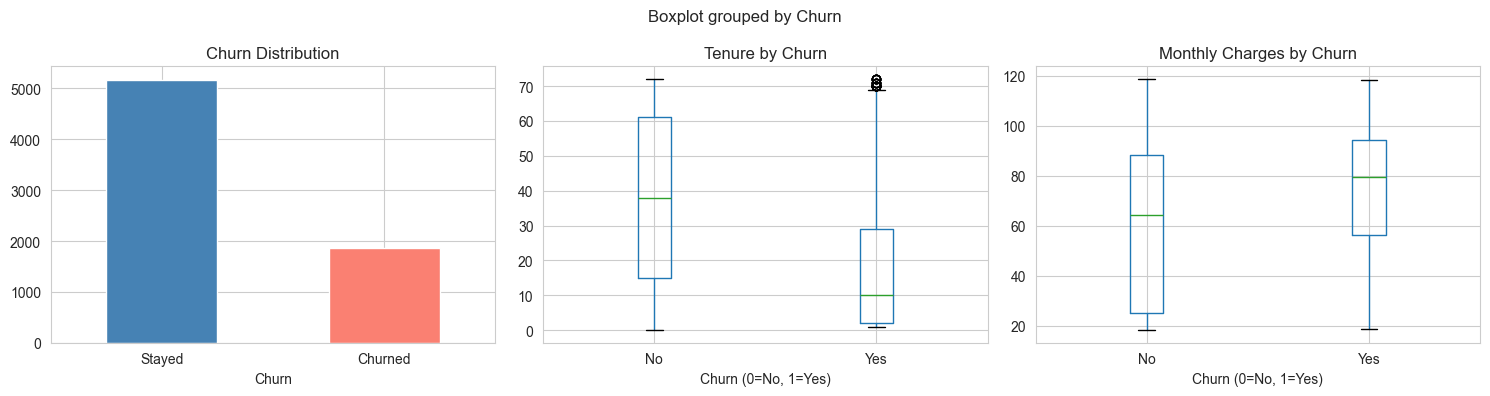

In [15]:
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Churn rate
df['Churn'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'salmon'])
axes[0].set_title('Churn Distribution')
axes[0].set_xticklabels(['Stayed', 'Churned'], rotation=0)

# Tenure vs Churn
df.boxplot(column='tenure', by='Churn', ax=axes[1])
axes[1].set_title('Tenure by Churn')
axes[1].set_xlabel('Churn (0=No, 1=Yes)')

# Monthly Charges vs Churn
df.boxplot(column='MonthlyCharges', by='Churn', ax=axes[2])
axes[2].set_title('Monthly Charges by Churn')
axes[2].set_xlabel('Churn (0=No, 1=Yes)')

plt.tight_layout()
plt.show()